In [1]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, precision_score, average_precision_score, recall_score, roc_auc_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('C:/Users/aksha/documents/data/Loan_default.csv')

In [3]:
df.head(2)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [5]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
df.isna().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [7]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
class FeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Example: add ratio of feature1 / feature2
        X['MonthlyIncome'] = X['Income'] // 12
        X['EMI'] = (((X['LoanAmount']*(X['InterestRate']/100))) + X['LoanAmount'])/(X['LoanTerm'])
        X['EMI'] = round(X['EMI'], 2)
        X['EMI/Income_ratio'] = np.where(X['MonthlyIncome']<=0, 0, X['EMI']/X['MonthlyIncome'])
        X['Post_DTI'] = X['DTIRatio'] + X['EMI/Income_ratio']
        X['age_post_dti'] = X['Age'] * X['Post_DTI']
        X['tenure_age_ratio'] = X['MonthsEmployed'] / (X['Age'] + 1e-6)
        X['debt_stress'] = X['EMI/Income_ratio'] * X['DTIRatio']
        X = X.drop(columns=['Income'])
        return X

In [9]:
pd.set_option('display.max_columns', None)

In [10]:
train, test = train_test_split(df, test_size=0.2)

In [11]:
test.shape, train.shape

((51070, 18), (204277, 18))

In [12]:
X = train.drop(columns=['LoanID', 'Default'])
y = train[['Default']]

In [13]:
num_cols = train.select_dtypes(include=['int', 'float']).columns.tolist()
cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()

In [14]:
train[num_cols].skew()

Age               0.001089
Income           -0.001842
LoanAmount       -0.001350
CreditScore       0.005029
MonthsEmployed   -0.000641
NumCreditLines   -0.000597
InterestRate      0.001894
LoanTerm         -0.002705
DTIRatio          0.001260
Default           2.394620
dtype: float64

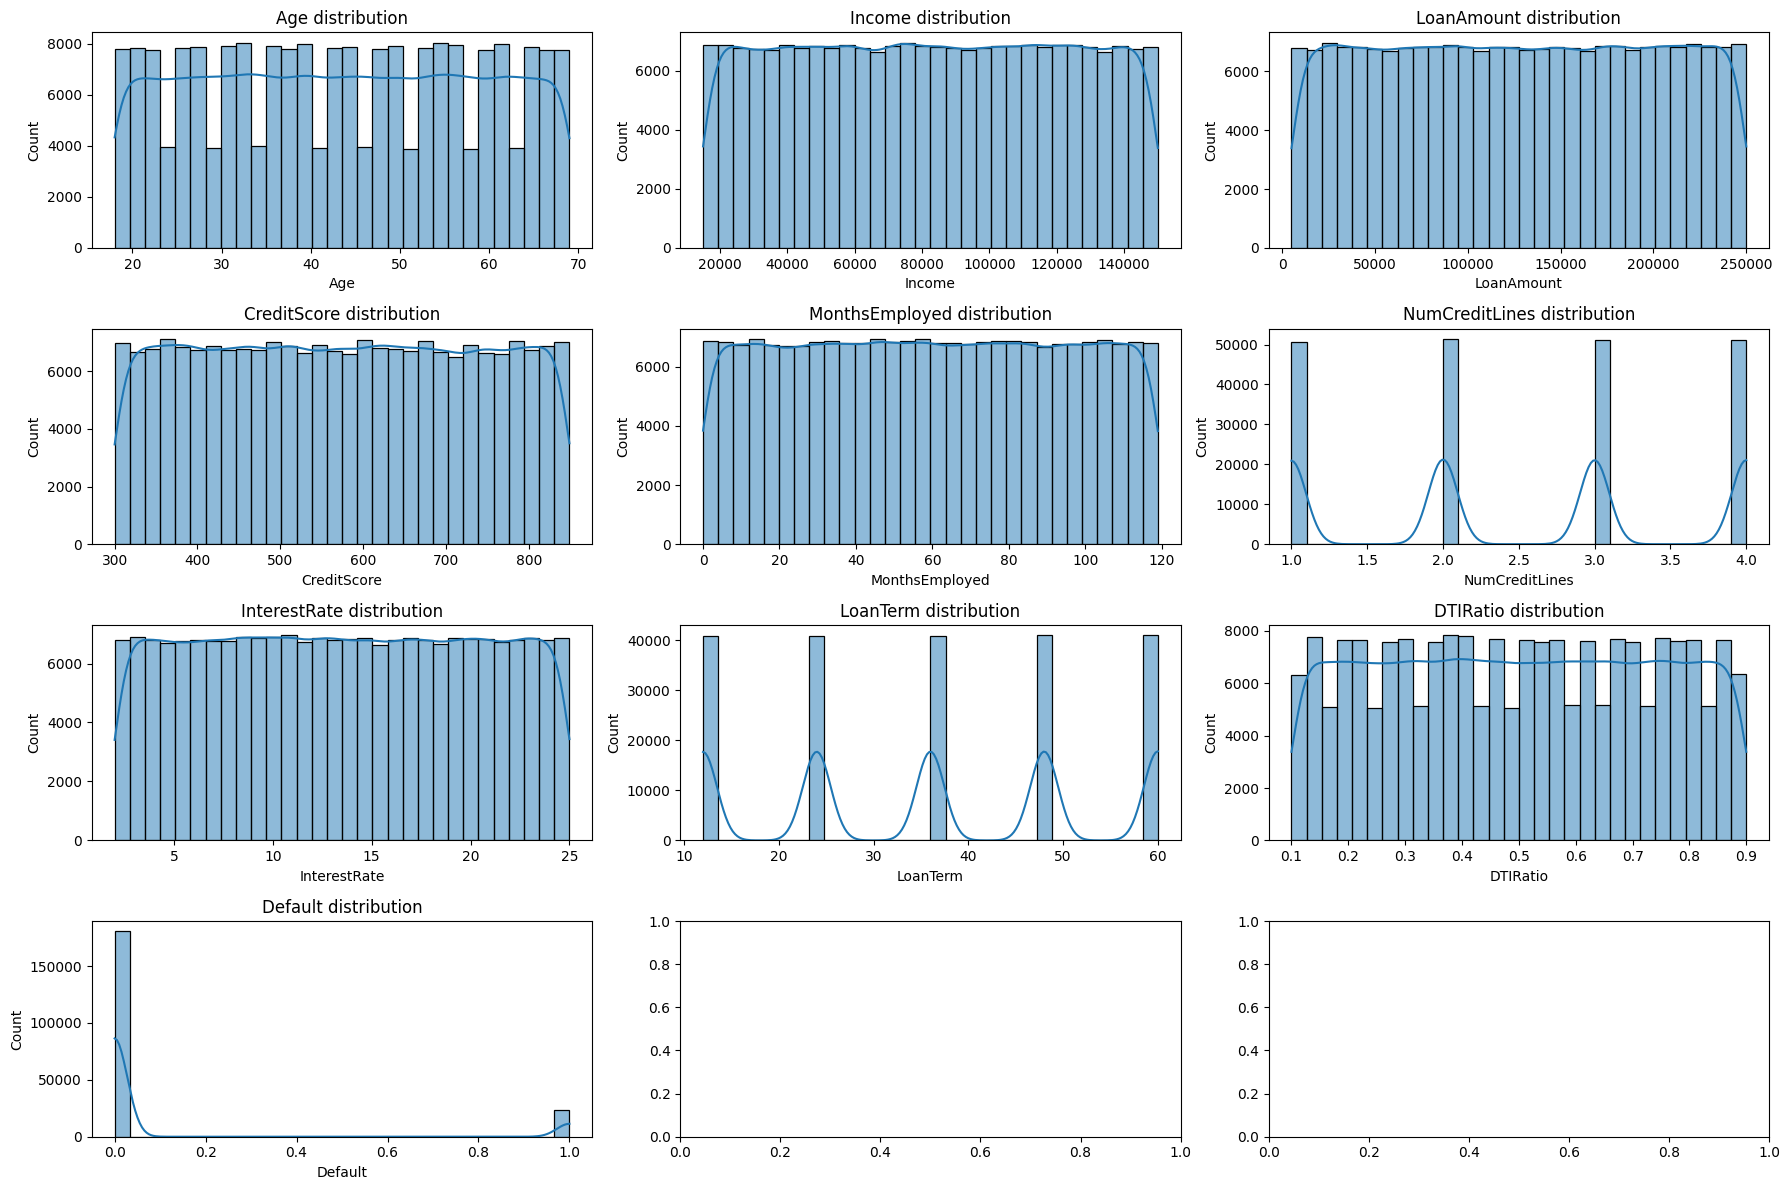

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(18, 12))  # 5*4 grid
axes = axes.flatten()   # flatten to easily iterate

for i, col in enumerate(num_cols):
    sns.histplot(train, x=col, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} distribution")

plt.tight_layout()
plt.show()

In [16]:
cat_cols.remove('LoanID')

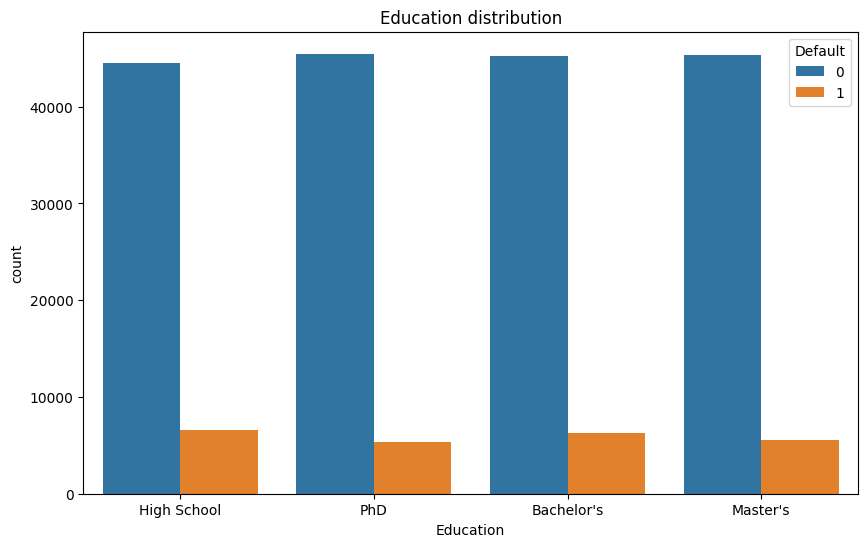

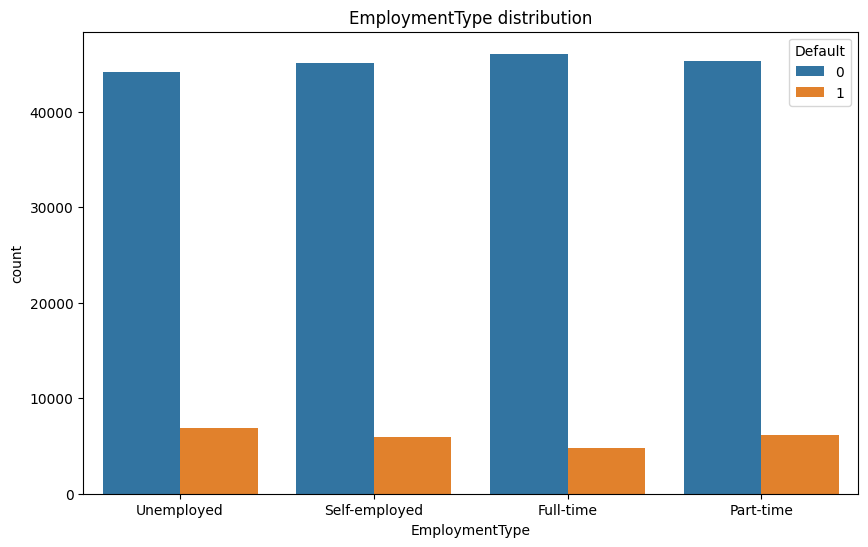

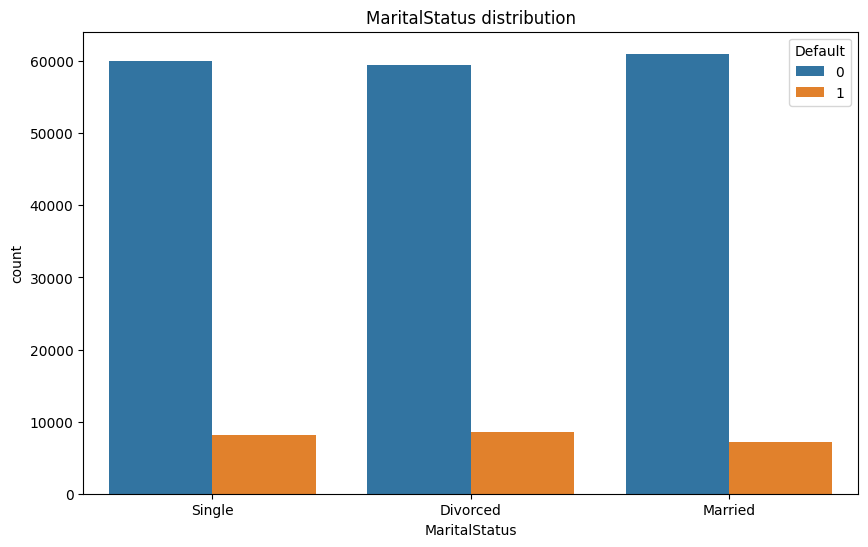

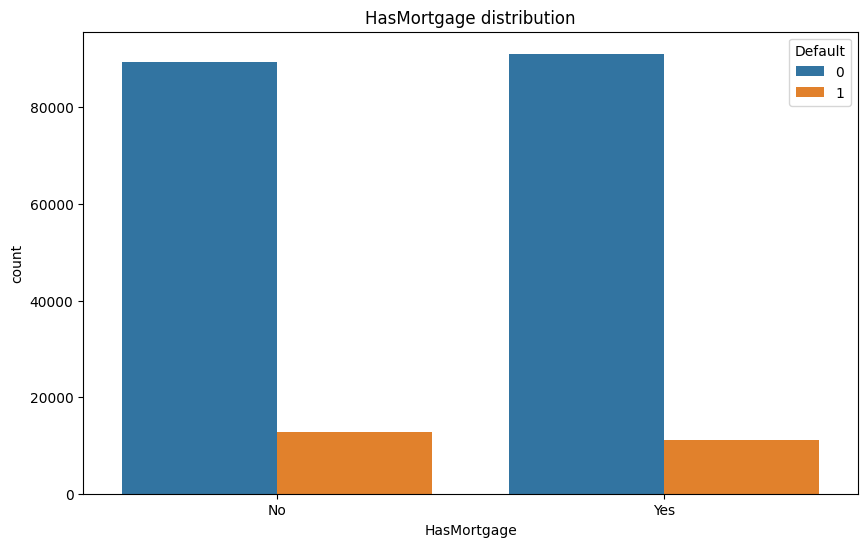

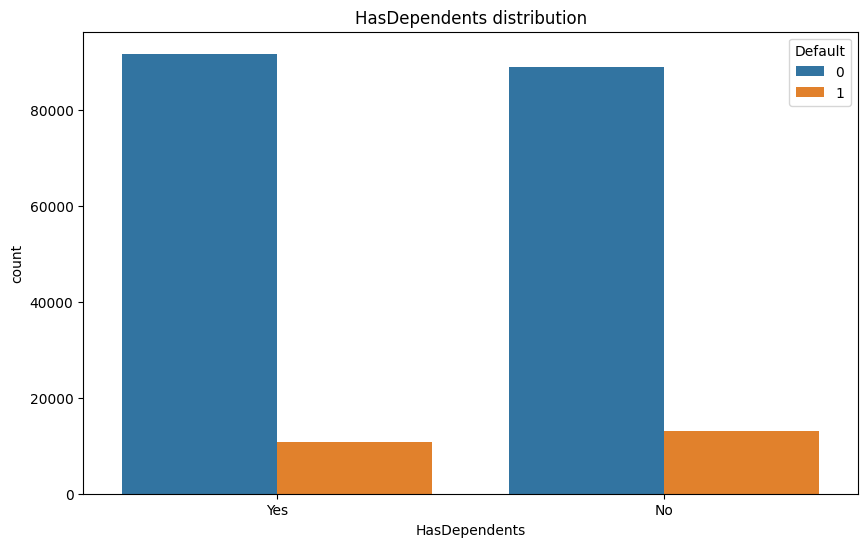

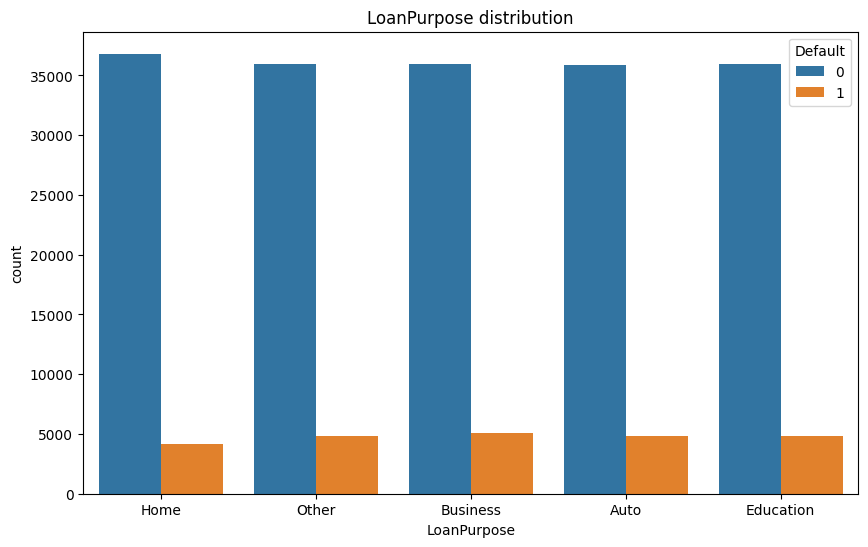

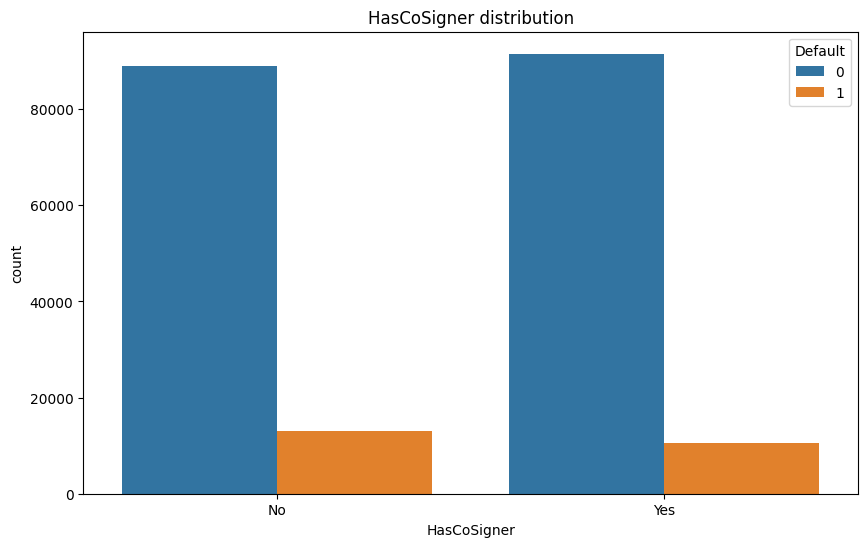

In [17]:
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(train, x=col, hue='Default')
    plt.title(f'{col} distribution')
    plt.show()

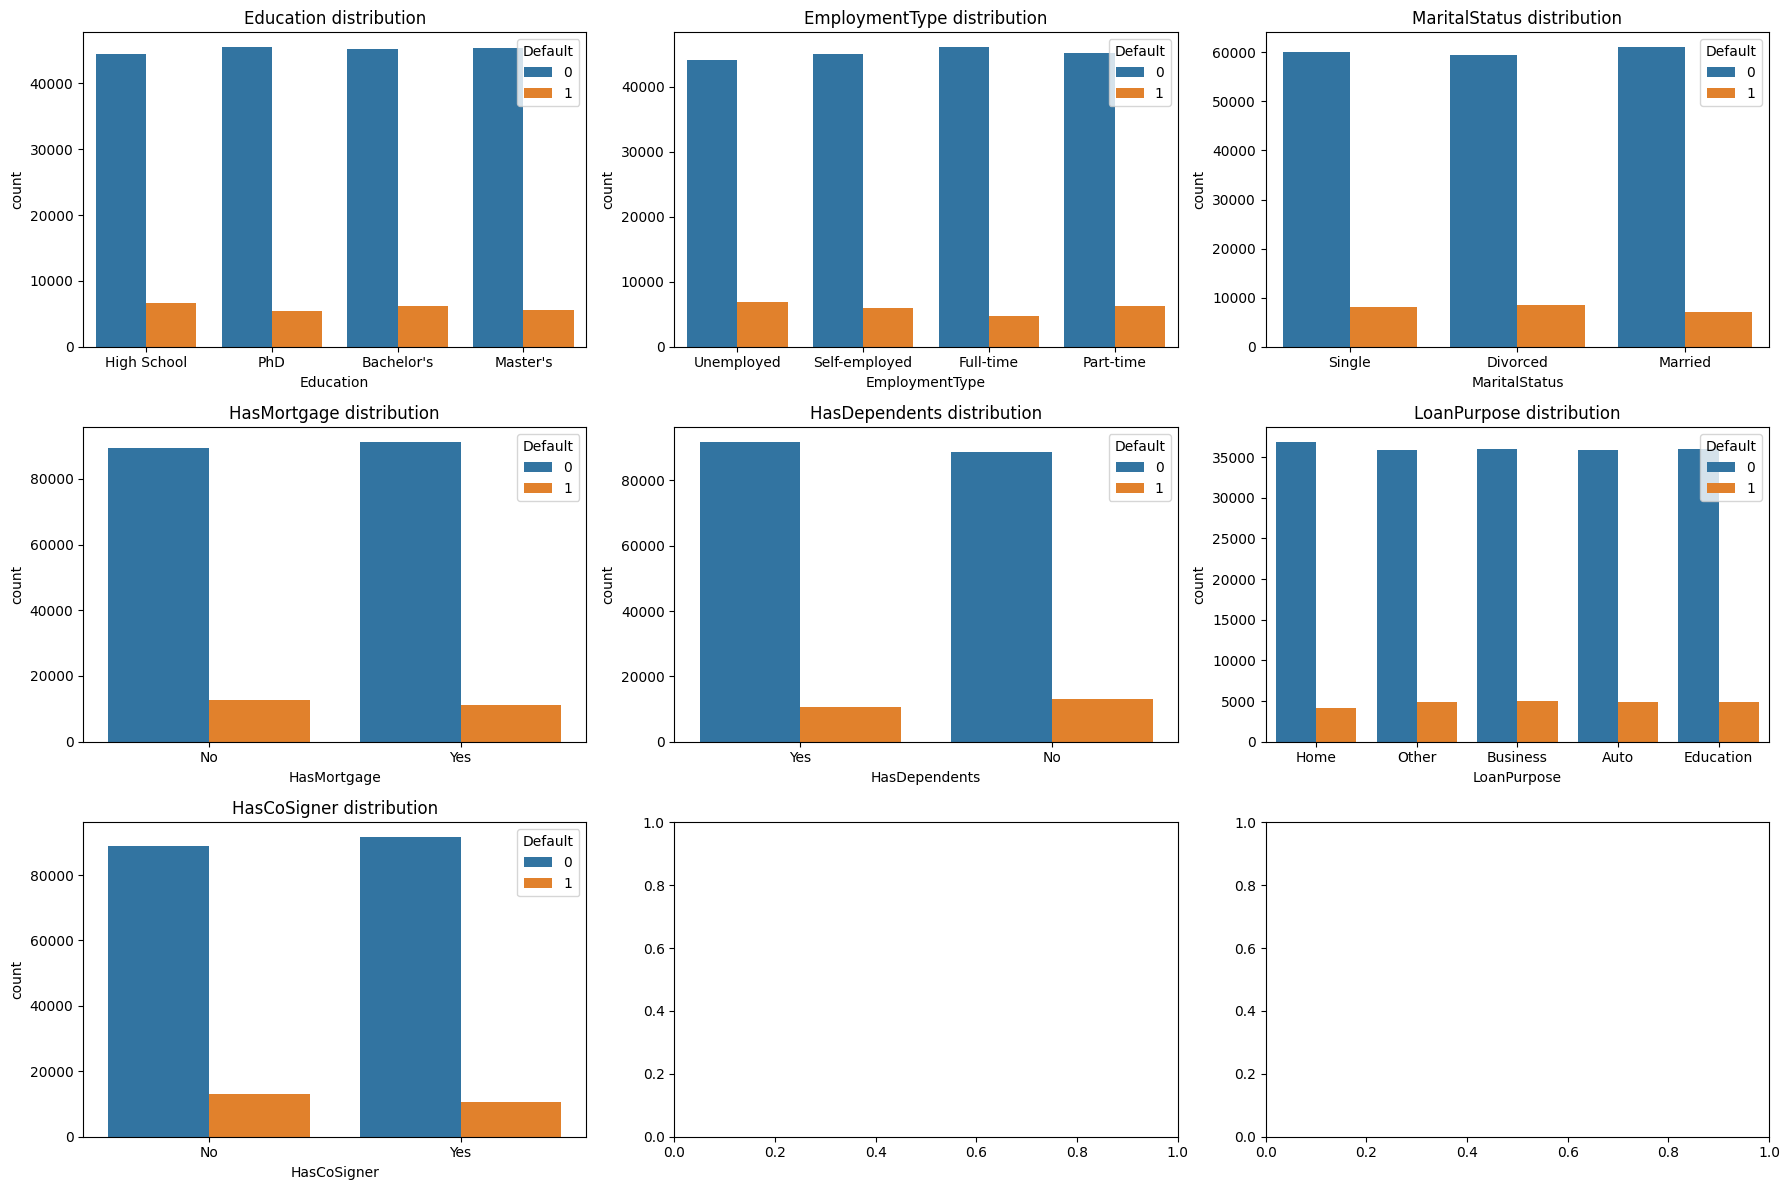

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))  # 5*4 grid
axes = axes.flatten()   # flatten to easily iterate

for i, col in enumerate(cat_cols):
    sns.countplot(train, x=col, hue='Default', ax=axes[i])
    axes[i].set_title(f"{col} distribution")

plt.tight_layout()
plt.show()

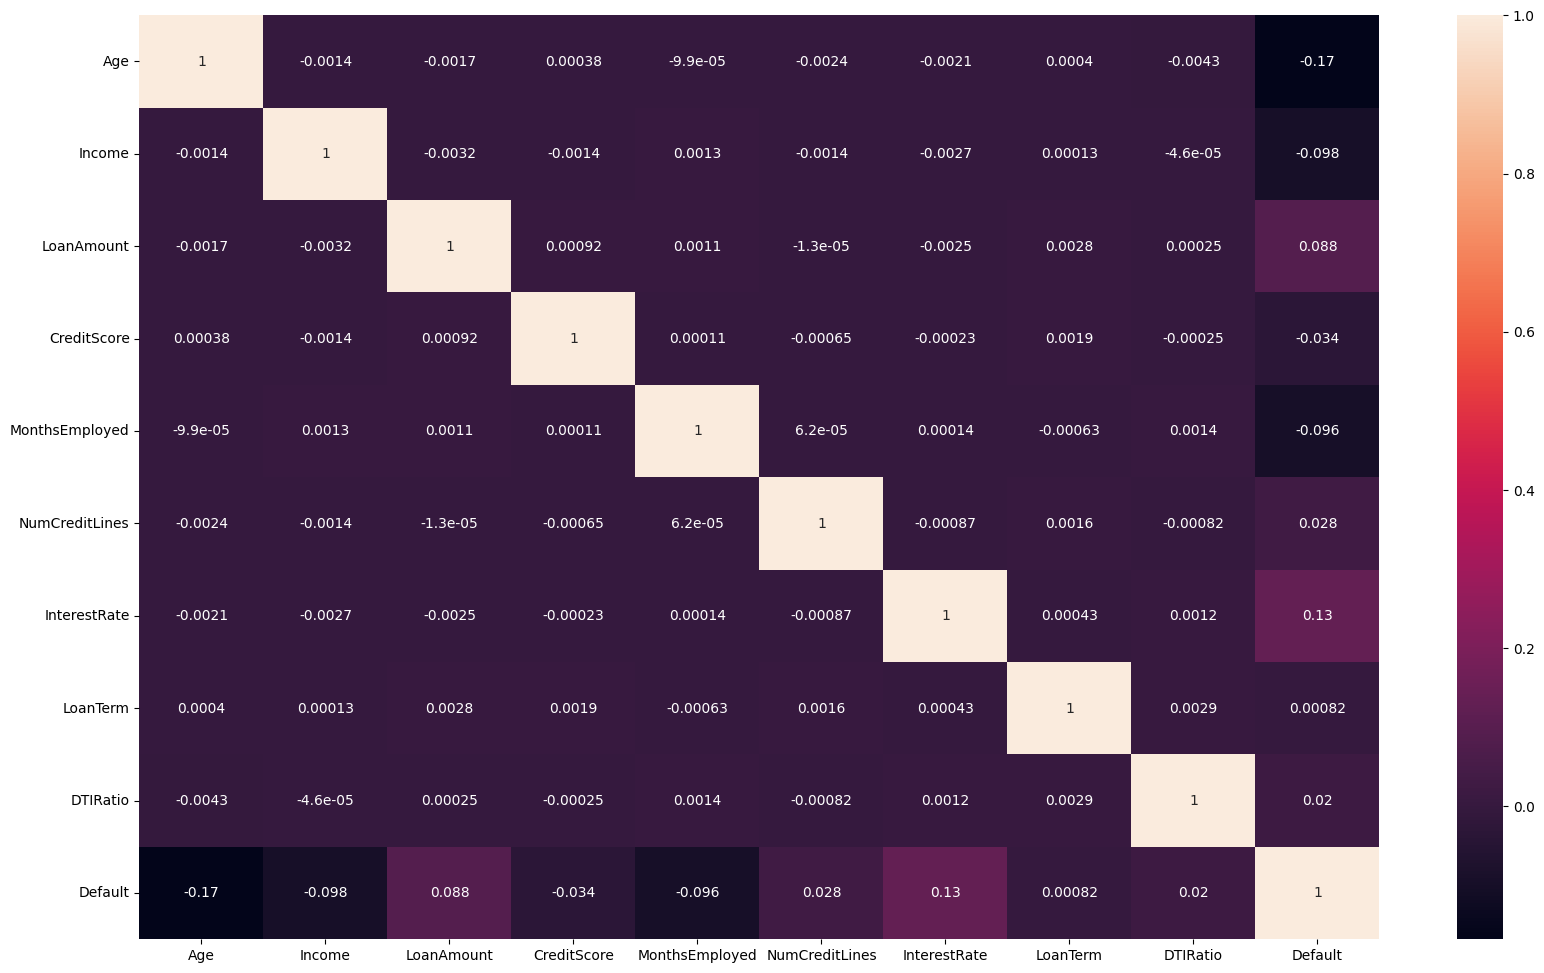

In [19]:
plt.figure(figsize=(20,12))
sns.heatmap(train[num_cols].corr(), annot=True)
plt.show()

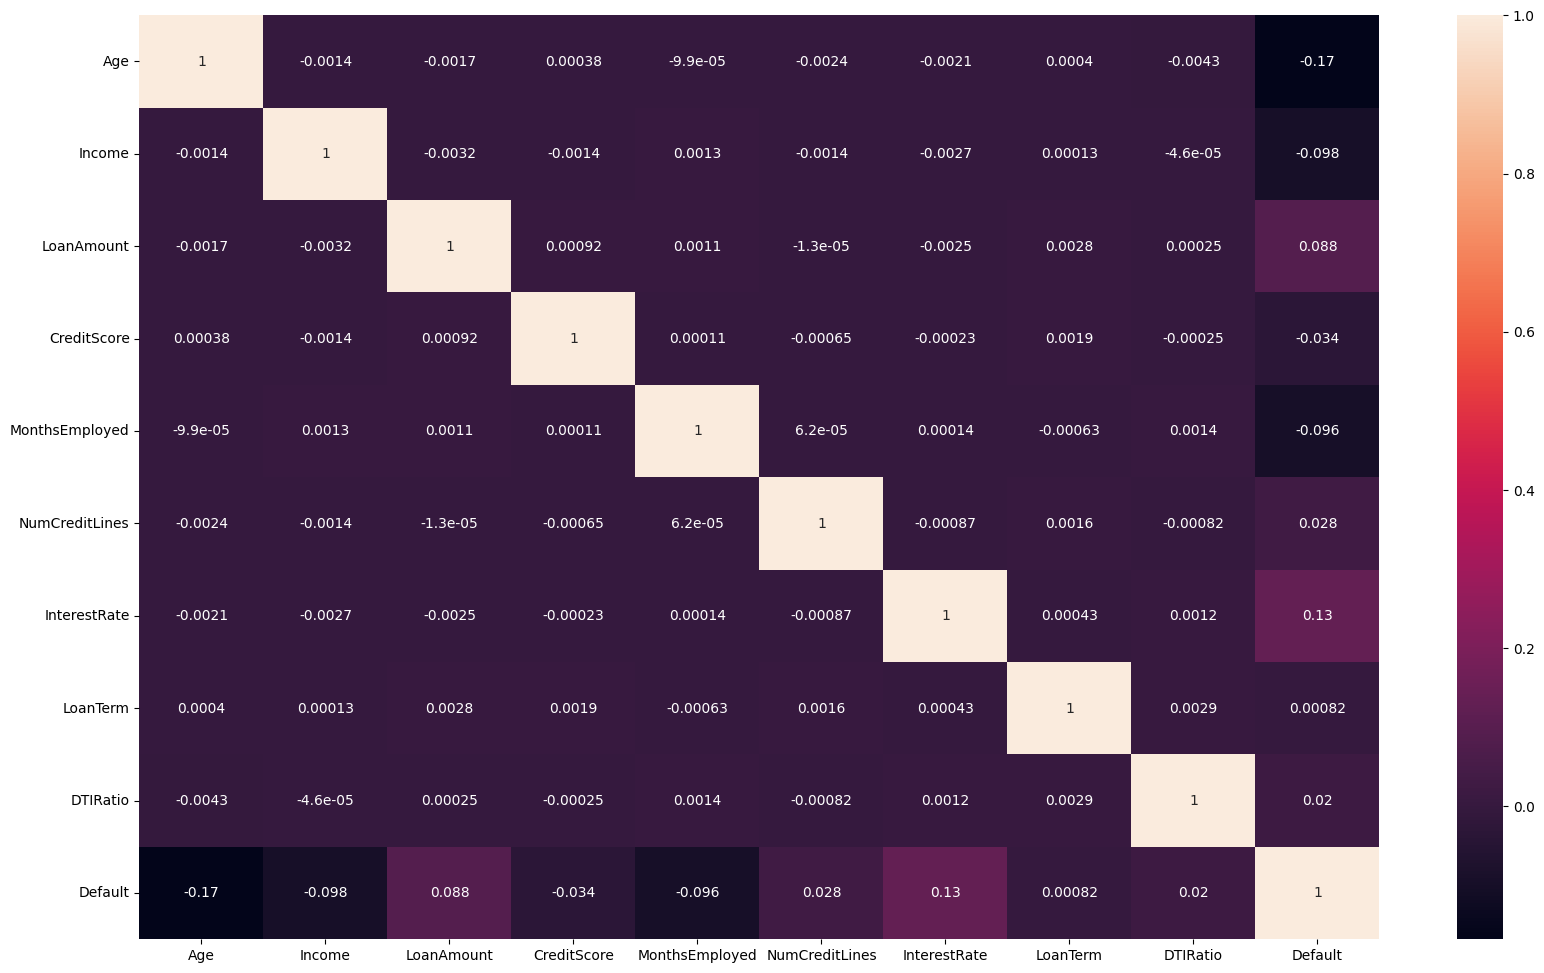

In [20]:
num_cols = train.select_dtypes(include=['int', 'float']).columns.tolist()
plt.figure(figsize=(20,12))
sns.heatmap(train[num_cols].corr(), annot=True)
plt.show()

In [21]:
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
234211,32,24183,162710,307,16,3,7.49,60,0.66,High School,Unemployed,Single,No,Yes,Home,No
101441,50,100314,20087,610,96,3,15.21,60,0.74,High School,Self-employed,Single,Yes,No,Home,Yes
9053,38,109284,180573,844,104,3,16.83,60,0.57,PhD,Full-time,Divorced,No,No,Other,No
247878,58,89791,200392,422,3,4,12.74,48,0.30,Bachelor's,Unemployed,Married,Yes,No,Home,Yes
52139,32,105616,46069,317,95,3,18.03,24,0.60,Bachelor's,Part-time,Divorced,No,No,Business,No


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((163421, 16), (40856, 16), (163421, 1), (40856, 1))

In [24]:
numeric_cols = X_train.select_dtypes(include=['int', 'float']).columns.tolist()
categoric_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [25]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

In [26]:
numeric_cols.remove('Income')

In [27]:
categoric_cols

['Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner']

In [28]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols),
    ('cat', cat_transformer, categoric_cols),
], remainder='passthrough')

In [29]:
y['Default'].value_counts()

Default
0    180531
1     23746
Name: count, dtype: int64

In [30]:
neg_count = np.sum(y['Default'] == 0)
pos_count = np.sum(y['Default'] == 1)

scale_pos_weight = neg_count / pos_count

In [31]:
scale_pos_weight = round(scale_pos_weight, 2)

In [32]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42,
        class_weight={0: 1.0, 1: scale_pos_weight},
        solver="lbfgs"
    ),
    'Ridge Classifier': RidgeClassifier(
        max_iter=2000, random_state=42,
        class_weight={0: 1.0, 1: scale_pos_weight},
        solver="lbfgs", positive=True
    ),
    'L1 Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42,
        class_weight={0: 1.0, 1: scale_pos_weight},
        l1_ratio=1.0, solver='saga'
    ),
    'L2 Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42,
        class_weight={0: 1.0, 1: scale_pos_weight},
        l1_ratio=0.0, solver="lbfgs"
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, max_depth=8,
        class_weight={0: 1.0, 1: scale_pos_weight}
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, max_depth=8, n_estimators=1000,
        class_weight={0: 1.0, 1: scale_pos_weight}
    ),
    'XGBoost': XGBClassifier(
        n_estimators=1000, max_depth=8,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
}

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin

class ConditionalLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1.0):
        self.threshold = threshold
        self.skewed_cols = []
    
    def fit(self, X, y=None):
        skewness = X[numeric_cols].skew()
        self.skewed_cols = skewness[skewness > self.threshold].index.tolist()
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in self.skewed_cols:
            # log1p handles zeros safely
            X[col] = np.log1p(X[col])
        return X

In [34]:
scoring = {'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall': 'recall',
           'F1': 'f1',
           'ROC_AUC_score' : 'roc_auc',
           'PR_AUC_score' : 'average_precision'}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
from sklearn.model_selection import cross_validate
rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('FE', FeatureAdder()),
        ('transformer', ConditionalLogTransformer(threshold=1.0)),
        ('preprocessing', preprocessor),
        ('ml_model', model)
    ])
    cv_scores = cross_validate(pipe, X_train, y_train.values.ravel(), cv=skf, scoring=scoring, n_jobs=1)
    rows.append({
        'Model_name': name,
        'cv_accuracy' : cv_scores['test_Accuracy'].mean(),
        'cv_precision' : cv_scores['test_Precision'].mean(),
        'cv_recall' : cv_scores['test_Recall'].mean(),
        'cv_F1' : cv_scores['test_F1'].mean(),
        'cv_roc_auc' : cv_scores['test_ROC_AUC_score'].mean(),
        'cv_pr_auc' : cv_scores['test_PR_AUC_score'].mean()  
    })

cv_results = pd.DataFrame(rows).sort_values(by="cv_recall")

In [36]:
cv_results.sort_values(by='cv_recall', ascending=False)

,Model_name,cv_accuracy,cv_precision,cv_recall,cv_F1,cv_roc_auc,cv_pr_auc
0,Logistic Regression,0.686319,0.223948,0.689310,0.338059,0.754240,0.316949
3,L2 Logistic Regression,0.686319,0.223948,0.689310,0.338059,0.754240,0.316949
4,Decision Tree,0.666359,0.204811,0.648236,0.311110,0.713629,0.267125
5,Random Forest,0.707547,0.229095,0.641285,0.337585,0.744411,0.306796
2,L1 Logistic Regression,0.703490,0.216215,0.591101,0.316605,0.713083,0.257652
1,Ridge Classifier,0.717680,0.195965,0.460769,0.274974,0.658707,0.206161
6,XGBoost,0.867594,0.351362,0.164771,0.224308,0.689919,0.250349


In [37]:
params = {
    'ml_model__alpha' : [0.01, 0.1, 1],
    "ml_model__max_iter": [100, 300, 500],
    "ml_model__solver" : ['auto', 'saga', 'lbfgs']
}

In [38]:
ridge_pipe = Pipeline(steps=[
    ('FE', FeatureAdder()),
    ('transformer', ConditionalLogTransformer(threshold=1.0)),
    ('preprocessing', preprocessor),
    ('ml_model', RidgeClassifier(random_state=42, class_weight={0:1.0, 1:scale_pos_weight}))
])
grid = GridSearchCV(ridge_pipe, params, cv=skf, scoring='recall', n_jobs=1)

In [39]:
grid.fit(X_train, y_train.values.ravel())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ml_model__alpha': [0.01, 0.1, ...], 'ml_model__max_iter': [100, 300, ...], 'ml_model__solver': ['auto', 'saga', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [40]:
best_score = grid.best_score_
best_params = grid.best_params_

In [41]:
best_score

0.6936282253817799

In [42]:
best_params

{'ml_model__alpha': 0.01,
 'ml_model__max_iter': 100,
 'ml_model__solver': 'auto'}

In [44]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'ml_model__max_iter': np.arange(100, 1000, 100),
    'ml_model__C': np.logspace(-3, 3, 10),
    'ml_model__l1_ratio': np.linspace(0.0, 1.0, 5),  # only used with saga
}

lg_pipe = Pipeline(steps=[
    ('FE', FeatureAdder()),
    ('transformer', ConditionalLogTransformer(threshold=1.0)),
    ('preprocessing', preprocessor),
    ('ml_model', LogisticRegression(random_state=42, class_weight={0:1.0, 1:scale_pos_weight}))
])

random = RandomizedSearchCV(lg_pipe, param_distributions, cv=skf, scoring='recall', n_jobs=1, verbose=0, n_iter=10)

random.fit(X_train, y_train.values.ravel())

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'ml_model__C': array([1.0000...00000000e+03]), 'ml_model__l1_ratio': array([0. , ..., 0.75, 1. ]), 'ml_model__max_iter': array([100, 2...00, 800, 900])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [45]:
best_score = random.best_score_
best_params = random.best_params_
print(best_score, best_params)

0.6896261190100053 {'ml_model__max_iter': 400, 'ml_model__l1_ratio': 0.0, 'ml_model__C': 2.154434690031882}


In [46]:
final_lg_pipe = Pipeline(steps=[
    ('FE', FeatureAdder()),
    ('transformer', ConditionalLogTransformer(threshold=1.0)),
    ('preprocessing', preprocessor),
    ('ml_model', LogisticRegression(max_iter=best_params['ml_model__max_iter'], 
                                    l1_ratio=best_params['ml_model__l1_ratio'],
                                    C=best_params['ml_model__C'],
                                    solver='lbfgs',
                                    tol=0.0001,
                                    random_state=42, 
                                    class_weight={0:1.0, 1:scale_pos_weight}))
])

In [47]:
final_lg_pipe.fit(X_train, y_train.values.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FE', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,threshold,1.0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [48]:
y_pred = final_lg_pipe.predict_proba(X_test)[:, 1]

In [49]:
print(roc_auc_score(y_test, y_pred))
print(average_precision_score(y_test, y_pred))

0.7467893362284468
0.3056206565342776


In [50]:
pred = (y_pred >= 0.45).astype(int)

In [51]:
print('Accuracy:', accuracy_score(y_test, pred))
print('Precision:', precision_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))
print('F1-score:', f1_score(y_test, pred))

Accuracy: 0.625097904836499
Precision: 0.20063495663019446
Recall: 0.7441126997476871
F1-score: 0.31605269033266353


In [52]:
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Classification report:\n", classification_report(y_test, pred))

Confusion Matrix:
 [[22000 14100]
 [ 1217  3539]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.61      0.74     36100
           1       0.20      0.74      0.32      4756

    accuracy                           0.63     40856
   macro avg       0.57      0.68      0.53     40856
weighted avg       0.86      0.63      0.69     40856



In [53]:
import mlflow

In [54]:
best_estimator = random.best_estimator_
best_params = random.best_params_
cv_recall = random.best_score_
test_accuracy = accuracy_score(y_test, pred)
test_recall = recall_score(y_test, pred)
test_precision = precision_score(y_test, pred)
test_f1 = f1_score(y_test, pred) 
test_cm = confusion_matrix(y_test, pred)
test_roc_auc = roc_auc_score(y_test, y_pred)
test_pr_auc = average_precision_score(y_test, y_pred)

In [55]:
best_estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FE', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,threshold,1.0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [56]:
fig, ax = plt.subplots()
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.close()

In [57]:
best_estimator.classes_

array([0, 1], dtype=int64)

In [58]:
mlflow.set_experiment("Loan_Risk_Assessment_Log_Reg_Experiments")

mlflow.autolog()

with mlflow.start_run(nested=True):
    
    # Log trained model artifact
    mlflow.sklearn.log_model(lg_pipe, "Log_Reg_model")

    # Log hyperparameters
    mlflow.log_params(best_params)

    # Log CV performance
    mlflow.log_metric("cv_mean_recall", round(cv_recall, 2))

    # Log final evaluation metrics
    mlflow.log_metric("test_accuracy", round(test_accuracy, 2))
    mlflow.log_metric("test_recall", round(test_recall, 2))
    mlflow.log_metric("test_precision", round(test_precision,2))
    mlflow.log_metric("test_f1", round(test_f1, 2))
    mlflow.log_metric("test_roc_auc", round(test_roc_auc, 2))
    mlflow.log_metric("test_roc_auc", round(test_roc_auc, 2))

    # confusion matrix
    mlflow.log_artifact("confusion_matrix.png")
    
print("Logged to MLflow successfully.")

2026/02/26 10:23:07 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/26 10:23:07 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/26 10:23:07 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/26 10:23:07 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/26 10:23:07 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/26 10:23:07 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/26 10:23:08 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/26 10:23:08 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/26 10:23:09 WARNING mlflow.tracking.fluent: Exception raised while enabling autologging for sklearn: [WinError 127] The specified procedure could not be found. Error loading "C:\Users\aksha\anaconda3\envs\ml_env\Lib\site-packages\torch\lib\shm.dll" or one of its dependenci

Logged to MLflow successfully.


In [59]:
import joblib
joblib.dump(lg_pipe, "C:/Users/aksha/documents/models/final_model_v3.joblib")

['C:/Users/aksha/documents/models/final_model_v3.joblib']

In [60]:
features = lg_pipe.named_steps['preprocessing'].get_feature_names_out()

In [61]:
test.to_csv('C:/Users/aksha/documents/data/test.csv', index=False)

In [62]:
cv_results.to_csv('C:/Users/aksha/documents/data/confusion_matrix.csv', index=False)

In [63]:
train.to_csv('C:/Users/aksha/documents/data/train.csv', index=False)

In [64]:
best_params

{'ml_model__max_iter': 400,
 'ml_model__l1_ratio': 0.0,
 'ml_model__C': 2.154434690031882}

In [65]:
features

array(['num__Age', 'num__LoanAmount', 'num__CreditScore',
       'num__MonthsEmployed', 'num__NumCreditLines', 'num__InterestRate',
       'num__LoanTerm', 'num__DTIRatio', "cat__Education_Bachelor's",
       'cat__Education_High School', "cat__Education_Master's",
       'cat__Education_PhD', 'cat__EmploymentType_Full-time',
       'cat__EmploymentType_Part-time',
       'cat__EmploymentType_Self-employed',
       'cat__EmploymentType_Unemployed', 'cat__MaritalStatus_Divorced',
       'cat__MaritalStatus_Married', 'cat__MaritalStatus_Single',
       'cat__HasMortgage_No', 'cat__HasMortgage_Yes',
       'cat__HasDependents_No', 'cat__HasDependents_Yes',
       'cat__LoanPurpose_Auto', 'cat__LoanPurpose_Business',
       'cat__LoanPurpose_Education', 'cat__LoanPurpose_Home',
       'cat__LoanPurpose_Other', 'cat__HasCoSigner_No',
       'cat__HasCoSigner_Yes', 'remainder__MonthlyIncome',
       'remainder__EMI', 'remainder__EMI/Income_ratio',
       'remainder__Post_DTI', 'remainder__ag

In [67]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(final_lg_pipe, X_test, y_test.values.ravel(), 
                                  scoring="recall", n_repeats=5, random_state=42)

In [68]:
features_imp_df = pd.DataFrame({
    'Features': X_test.columns.tolist(),
    'Importances': perm_imp.importances_mean
}).sort_values(by='Importances', ascending=False)

In [69]:
features_imp_df.head()

,Features,Importances
0,Age,0.114844
6,InterestRate,0.073675
1,Income,0.047098
4,MonthsEmployed,0.039066
2,LoanAmount,0.035029


In [70]:
features_imp_df.to_csv('C:/Users/aksha/documents/data/Features_imp.csv', index=False)